# DashAnalysis Tool

This notebook exercises both volume and point-cloud slicing using `DashAnalysis.slice_data` with the simple object flow:

```python
data = da.load_data(path)
data.points
data.intensities
sl_data = da.slice_data(data)
lc_data = da.line_cut(data)
```

- Volume: slice via PyVista using a plane (`normal`, `origin`).
- Points: select only points near the specified plane and interpolate onto that plane.

In [ ]:
import numpy as np
import pyvista as pv
import importlib
import dash_analysis as dash

# Reload the module to ensure latest changes are picked up in the notebook kernel
importlib.reload(dash)
da = dash.DashAnalysis()

In [5]:
# Try loading a real HDF5 file; fall back to synthetic data if unavailable
tfile = "/home/beams18/USER6IDB/hdf5/hio227_113.h5"  # change to your file path as needed
data = da.load_data(tfile)
print("Data points length ",len(data.points))

Loading to 
Loading 3D data from: /home/beams18/USER6IDB/hdf5/hio227_113.h5
Validating File
file valid
Raw data keys: ['qx', 'qy', 'qz', 'images', 'num_images', 'image_shape', 'metadata']
QX shape: (34, 516, 516)
Images shape: (34, 516, 516)
3D validation passed: (34, 516, 516) points
Flattened coordinates: qx=9052704, qy=9052704, qz=9052704
Created 3D points array: (9052704, 3)
Data points length  9052704


In [6]:
da.show_meta(data)

{'valid': False,
 'data_type': '',
 'paths': [],
 'shapes': {},
 'dtypes': {},
 'entry_attrs': {},
 'data_attrs': {},
 'metadata': {}}

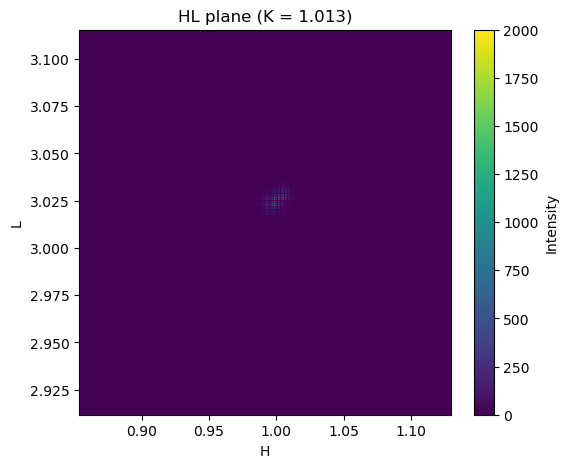

In [14]:
# This will take about 8-12 Seconds
sl_data = da.slice_data(data, hkl="HL", shape=(256,256), grid_origin=(1,0,2.7), slab_thickness=1e-3)

da.show_slice(sl_data, cmap='viridis', clim=(0,2000))

In [15]:
sl_3d_data = da.slice_data(data=(data.points, data.intensities), hkl='HL', shape=(800,800), slab_thickness=2.0,spacing=(0.5,0.5,0.5))

print(type(sl_3d_data))

<class 'pyvista.core.pointset.PolyData'>


In [ ]:
p = pv.Plotter(notebook=True)               # create a notebook plotter
p.add_axes(xlabel='H', ylabel='K', zlabel='L')  # label axes
p.add_mesh(sl_3d_data, scalars='intensity',
           render_points_as_spheres=True, 
           point_size=2.0,
           opacity=0.15, 
           cmap='viridis', 
           name='points')  # context layerda.show_vol(sl_data.points, sl_data['intensity'])

# Add the 3D slice surface using its intensity
p.add_mesh(sl_3d_data, scalars='intensity', cmap='magma', show_scalar_bar=True, name='slice')  # main slice layer
p.show()

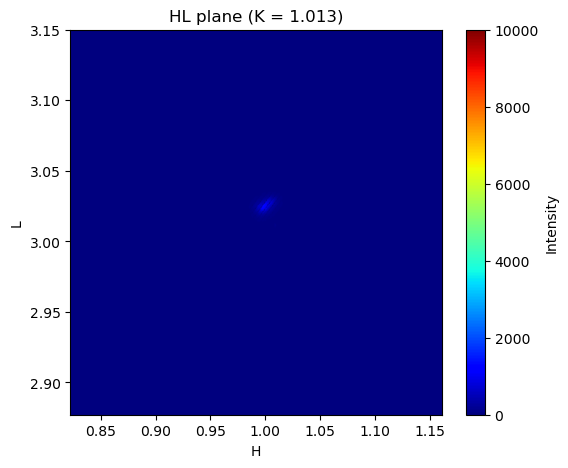

In [16]:
da.show_slice(sl_3d_data, cmap='jet', clim=(0,10000))

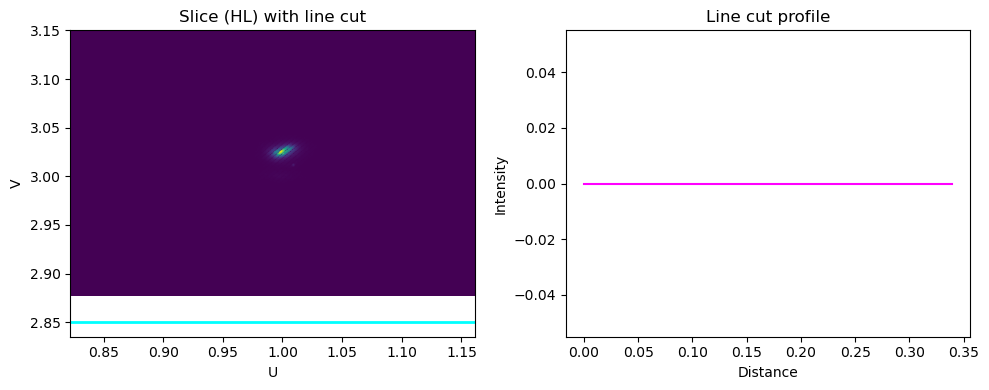

In [17]:
lc_data = da.line_cut("zero", param=(2.85, "x"), vol=sl_3d_data)

In [ ]:
lc_data = da.line_cut("positive", vol=sl_3d_data, n_samples=1024, width_px=3)

In [ ]:
lc_data = da.line_cut("infinite", param=(1.0, "y"), vol=sl_3d_data, interactive=True)

In [ ]:
lc_data = da.line_cut(((1.1,1.75),(0.93,3.00)), vol=sl_3d_data, interactive=True)

In [ ]:
da.show_point_cloud(data.points,data.intensities, clim=(0.0,1000000.0), opacity=(0.))

In [22]:
max(data.intensities)
#min(data.intensities)

np.uint32(351998)

In [ ]:
da.show_point_cloud(data.points,data.intensities, clim=(200,351998), hide_out_of_range=True, cmap='jet', opacity_range=(0.1,0.8))

Widget(value='<iframe src="http://localhost:40387/index.html?ui=P_0x7f650bb24b50_3&reconnect=auto" class="pyvi…